# Applying TDA to US house of representatives voting data
Goal: Reproduce the results from the paper "Extracting insights from the shape of complex data using topology" (https://www.nature.com/articles/srep01236)

Method: We intend to use the python package kmapper to apply the mapper algorithm to the minimal dataset, created in `TDA_practical/exploratory/data_csv_structure.ipynb`


## TEMPORARY
Copied code from Exercise sheet 4 on mapper

In [ ]:
import numpy as np
import sklearn
import kmapper as km
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from sklearn.neighbors import KernelDensity

data_raw = pd.DataFrame.to_numpy(df_data.drop(['group'], axis=1))

scaler=MinMaxScaler()
data=scaler.fit_transform(data_raw)
data-=np.mean(data,axis=0)
data

#Initalize Mapper and DBscan as clustering method
mapper = km.KeplerMapper(verbose=2)
cluster_method=sklearn.cluster.DBSCAN(eps=0.7,min_samples=2)

#Simple gaussian kernel KDE filter 
def sklearn_density_filter(X, bandwidth):
    """
    Returns estimated density values at the sample points.
    """
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)
    kde.fit(X)

    log_density = kde.score_samples(X)   
    density = np.exp(log_density)
    return log_density

density = sklearn_density_filter(data, bandwidth=0.3)

lens = density.reshape(-1, 1)

#Create cover similar to paper
cover=km.Cover(n_cubes=4, perc_overlap=0.5)

#Create graph
graph = mapper.map(
    lens,
    data,
    clusterer=cluster_method,
    cover=cover
)

# Visualize density values
#mapper.visualize(graph, path_html="diabetes.html",color_values=density,color_function_name="KDE density")

# Visualize group colors
mapper.visualize(graph, path_html="diabetes.html",color_values=labels,color_function_name="diabetes type")

# First try on mapper implementation: 

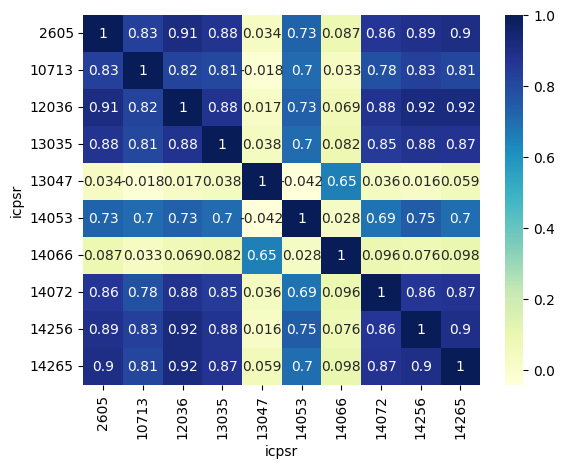

In [20]:
import pandas as pd
import numpy as np
import kmapper as km
import matplotlib.pyplot as plt
import seaborn as sns

df_data = pd.read_csv("../data/processed_data.csv")

vote_matrix_09 = df_data[df_data['date'] < '2010-01-01'].pivot(index='icpsr', columns='rollnumber', values='paper_cast_code').fillna(0)
vote_matrix_10 = df_data[df_data['date'] >= '2010-01-01'].pivot(index='icpsr', columns='rollnumber', values='paper_cast_code').fillna(0)

corr_09 = vote_matrix_09.T.corr()
corr_10 = vote_matrix_10.T.corr()

sns.heatmap(corr_09.iloc[:10, :10], cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()
